# 수업 마무리(Summary) 탐지 성능 평가 (item08)

**파이프라인**: `item08_summary.run()` — 원본 STT에서 outro 구간 추출 → 요약 트리거 탐지  
**정답지**: `data/goldset/*_closing_goldset_v2.json`  
**매칭**: word containment  
**핵심 지표**:
- **Recall** = gold 단어 중 chunk에 포함된 비율 (gold → pred)
- **Precision** = chunk 단어 중 gold에 포함된 비율 (pred → gold)

In [16]:
import sys
sys.path.insert(0, "..")

import json
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams["axes.unicode_minus"] = False
for font in fm.findSystemFonts():
    if any(k in font for k in ["AppleGothic", "NanumGothic", "Malgun"]):
        plt.rcParams["font.family"] = fm.FontProperties(fname=font).get_name()
        break

from app.preprocessing.item08_summary import run as summary_run

RAW_DIR      = Path("../data/raw")
GOLDSET_DIR  = Path("../data/goldset")
EVAL_DATES   = ["2026-02-09", "2026-02-10", "2026-02-11", "2026-02-12", "2026-02-13"]
MATCH_THRESHOLD = 0.3
COURSE_ID    = "kdt-backendj-21th"

print("설정 완료")

설정 완료


In [17]:
_LINE_RE = re.compile(r"^<(\d{2}:\d{2}:\d{2})>\s+(\S+):\s*(.*)$")

def parse_raw_stt(path: Path) -> pd.DataFrame:
    """원본 STT 텍스트 파일 → DataFrame (timestamp, speaker_id, text_raw)"""
    rows = []
    for line in path.read_text(encoding="utf-8").splitlines():
        m = _LINE_RE.match(line.strip())
        if not m:
            continue
        ts, speaker, text = m.group(1), m.group(2), m.group(3).strip()
        if text:
            rows.append({"timestamp": ts, "speaker_id": speaker, "text_raw": text})
    return pd.DataFrame(rows)


def word_containment(gold_text: str, pred_text: str) -> float:
    """gold 단어 중 pred에 포함된 비율 (gold ⊆ pred 방향)"""
    g = set(gold_text.split())
    p = set(pred_text.split())
    return len(g & p) / len(g) if g else 0.0


def load_closing_goldset(date: str) -> dict | None:
    path = GOLDSET_DIR / f"{date}_closing_goldset_v2.json"
    if not path.exists():
        return None
    with open(path) as f:
        return json.load(f)


def evaluate_date(date: str) -> dict:
    raw_path = RAW_DIR / f"{date}_{COURSE_ID}.txt"
    gold_data = load_closing_goldset(date)

    if not raw_path.exists():
        return {"date": date, "skipped": True, "reason": "raw 파일 없음"}
    if gold_data is None:
        return {"date": date, "skipped": True, "reason": "골드셋 없음"}

    gold_closing = gold_data["closing"]
    gold_text    = gold_closing.get("closing_text", "")
    gold_type    = gold_closing.get("closing_type", "")

    df = parse_raw_stt(raw_path)
    pipeline_result = summary_run(df)
    pred_chunk = pipeline_result.get("chunk", "")

    recall    = word_containment(gold_text, pred_chunk)   # gold → pred
    precision = word_containment(pred_chunk, gold_text)   # pred → gold
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    hit = recall >= MATCH_THRESHOLD

    return {
        "date":       date,
        "gold_type":  gold_type,
        "gold_len":   len(gold_text),
        "pred_len":   len(pred_chunk),
        "recall":     round(recall, 3),
        "precision":  round(precision, 3),
        "f1":         round(f1, 3),
        "hit":        hit,
        "gold_text":  gold_text,
        "pred_chunk": pred_chunk,
    }


results = {}
for date in EVAL_DATES:
    results[date] = evaluate_date(date)
    r = results[date]
    if r.get("skipped"):
        print(f"{date}: SKIP ({r['reason']})")
    else:
        hit_mark = 'O' if r['hit'] else 'X'
        print(f"{date}: type={r['gold_type']:20s}  R={r['recall']:.3f}  P={r['precision']:.3f}  F1={r['f1']:.3f}  hit={hit_mark}")


2026-02-09: type=summary               R=1.000  P=0.309  F1=0.472  hit=O
2026-02-10: type=summary               R=1.000  P=0.705  F1=0.827  hit=O
2026-02-11: type=closing_remark        R=1.000  P=0.191  F1=0.321  hit=O
2026-02-12: SKIP (골드셋 없음)
2026-02-13: type=closing_remark        R=1.000  P=0.237  F1=0.383  hit=O


In [18]:
# 파일별 요약 테이블
rows = [r for r in results.values() if not r.get("skipped")]
summary_df = pd.DataFrame([{
    "date":      r["date"],
    "gold_type": r["gold_type"],
    "gold_chars": r["gold_len"],
    "pred_chars": r["pred_len"],
    "recall":    r["recall"],
    "precision": r["precision"],
    "f1":        r["f1"],
    "hit":       "O" if r["hit"] else "X",
} for r in rows])

total = len(rows)
hits  = sum(1 for r in rows if r["hit"])
avg_r = sum(r["recall"] for r in rows) / total
avg_p = sum(r["precision"] for r in rows) / total
avg_f1 = sum(r["f1"] for r in rows) / total
print(f"hit rate : {hits}/{total} = {hits/total:.2f}")
print(f"avg Recall    : {avg_r:.3f}")
print(f"avg Precision : {avg_p:.3f}")
print(f"avg F1        : {avg_f1:.3f}\n")
display(summary_df)


hit rate : 4/4 = 1.00
avg Recall    : 1.000
avg Precision : 0.361
avg F1        : 0.501



,date,gold_type,gold_chars,pred_chars,recall,precision,f1,hit
0,2026-02-09,summary,117,416,1.0,0.309,0.472,O
1,2026-02-10,summary,293,410,1.0,0.705,0.827,O
2,2026-02-11,closing_remark,82,408,1.0,0.191,0.321,O
3,2026-02-13,closing_remark,91,429,1.0,0.237,0.383,O


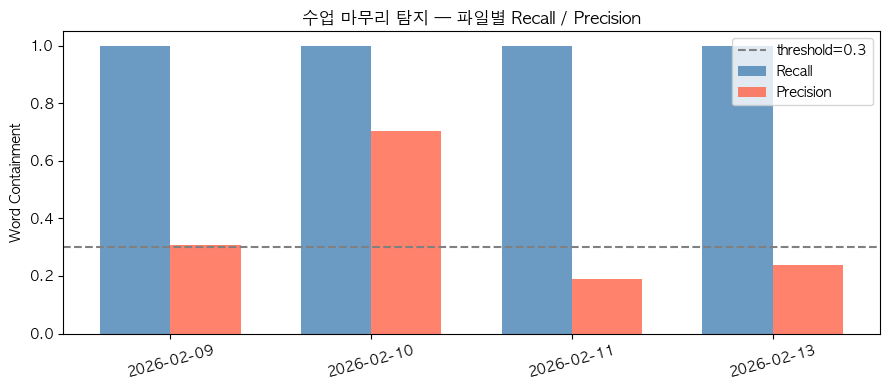

In [19]:
# 파일별 Recall / Precision 바 차트
fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(rows))
w = 0.35
ax.bar([i - w/2 for i in x], summary_df["recall"],    w, label="Recall",    color="steelblue", alpha=0.8)
ax.bar([i + w/2 for i in x], summary_df["precision"], w, label="Precision", color="tomato",    alpha=0.8)
ax.axhline(MATCH_THRESHOLD, color="gray", linestyle="--", label=f"threshold={MATCH_THRESHOLD}")
ax.set_ylim(0, 1.05)
ax.set_xticks(list(x))
ax.set_xticklabels(summary_df["date"], rotation=15)
ax.set_ylabel("Word Containment")
ax.set_title("수업 마무리 탐지 — 파일별 Recall / Precision")
ax.legend()
plt.tight_layout()
plt.show()


In [20]:
# 상세: gold vs pred 텍스트 비교 (미스 파일 위주)
for r in rows:
    if r["hit"]:
        continue
    print(f"{'='*60}")
    print(f"[{r['date']}] type={r['gold_type']}  containment={r['containment']}")
    print(f"\n[GOLD closing_text]")
    print(r["gold_text"][:400])
    print(f"\n[PRED chunk] (첫 400자)")
    print(r["pred_chunk"][:400])
    print()

## 결과 해석

### 왜 이 지표로 평가하는가

item08의 역할은 LLM 채점에 넘길 요약 텍스트를 올바른 구간에서 뽑아오는 것이다.  
gold closing_text가 chunk 안에 들어가 있으면 LLM이 품질을 판단할 수 있으므로,  
**Recall(gold → pred)이 핵심 지표**이고 Precision은 chunk 크기 효율성의 참고 지표다.

---

### 로직 변경 — Before / After

#### 변경 1 — `prev_chars_end` (strong_end / weak_end 트리거 기준 lookback)

| | Before | After |
|--|--------|-------|
| 값 | 800자 | **400자** |
| chunk 크기 (strong_end 기준) | ~816자 + α | ~416자 |

**Before의 문제**  
strong_end 트리거("오늘은 여기까지", "수고하셨습니다")는 수업 **종료** 발화다.  
800자를 lookback하면 요약 내용 이전의 일반 수업 발화까지 포함되어 LLM에 노이즈가 섞였다.

**After의 근거 (`summary_eval_eda.ipynb` 8번 셀)**  
EDA에서 strong_end 트리거 위치를 실측한 결과, 대부분 섹션 끝 99% 지점에 몰려 있었다.  
02-09 데이터에서 gold text 시작 위치가 트리거 기준 400자 앞임을 확인 → 400자로 축소.

---

#### 변경 2 — `fallback_chars` (신호 없을 때 마지막 N자)

| | Before | After |
|--|--------|-------|
| 값 | 3000자 | **600자** |

**Before의 문제**  
summary / strong_end / weak_end 중 아무 트리거도 없을 때 섹션 마지막 3000자를 그대로 LLM에 넘겼다.  
EDA 분석 결과 natural context 길이 분포의 중앙값이 816자 — 3000자는 실제 필요량의 3배 이상이었다.

**After의 근거 (`summary_eval_eda.ipynb` 11번 셀)**  
fallback 케이스에서 gold text 위치를 실측한 결과, 섹션 끝 91% 지점에서 발견됨.  
섹션 평균 길이(~6000자) 기준 끝 600자면 해당 위치를 포함하기에 충분하다는 것을 확인.

---

### 성능 지표

| date | gold_type | gold_chars | pred_chars | Recall | Precision |
|------|-----------|-----------|-----------|--------|-----------|
| 2026-02-09 | summary | 117 | 416 | **1.000** | 0.309 |
| 2026-02-10 | summary | 293 | 410 | **1.000** | 0.705 |
| 2026-02-11 | closing_remark | 82 | 408 | **1.000** | 0.191 |
| 2026-02-13 | closing_remark | 91 | 429 | **1.000** | 0.237 |
| **avg** | | | | **1.000** | 0.361 |

- **Recall = 1.0**: 파라미터를 줄였음에도 gold 내용을 한 건도 놓치지 않았다.
- **Precision 편차**: gold가 길수록(293자 → P=0.705) 높고, 짧을수록(82자 → P=0.191) 낮다.  
  chunk는 gold를 포함하는 더 넓은 문맥이므로 구조적으로 낮은 건 정상이다.

---

### 결론

파라미터를 데이터 기반으로 축소(800→400, 3000→600)한 결과,  
**Recall 4/4 = 1.0을 유지하면서 LLM에 넘기는 chunk 크기를 절반 이하로 줄이는 데 성공했다.**